# CT Scan Classification Notebook

This notebook trains and evaluates two image classifiers for CT scan images:

1. a small baseline CNN, used as a simple reference model;
2. a ResNet18-style model trained from scratch, used as the stronger comparison model.

The workflow is: load data, inspect class balance, train a model, evaluate it on the test set, generate Grad-CAM explanations, and save the final results.


## 0. Notebook Setup

This cell only keeps the notebook output easier to read by suppressing non-critical warnings.


In [1]:
# Keep notebook output focused by hiding non-critical warnings.
import warnings

warnings.filterwarnings("ignore")


## 1. Load the CT Scan Dataset

The dataset is expected to use one folder per class inside `data/train`, `data/valid`, and `data/test`. The custom `CTScanFolderDataset` reads those folders, converts images to RGB, applies the selected transform, and returns a dictionary with `image`, `label`, and `path`.

Training images use light augmentation. Validation and test images only use resizing, tensor conversion, and normalization so evaluation stays deterministic.


In [2]:
from src.data.data import CTScanFolderDataset
from src.transforms.ct_transforms import get_train_transforms, get_eval_transforms

IMAGE_SIZE = 224

# Training uses light augmentation. Validation and test use deterministic preprocessing.
train_transform = get_train_transforms(IMAGE_SIZE)
eval_transform = get_eval_transforms(IMAGE_SIZE)

trainDataSet = CTScanFolderDataset("data/train", train_transform)
validDataSet = CTScanFolderDataset("data/valid", eval_transform)
testDataSet = CTScanFolderDataset("data/test", eval_transform)

print("Number of train samples:", len(trainDataSet))
print("Number of validation samples:", len(validDataSet))
print("Number of test samples:", len(testDataSet))

print("Classes:", trainDataSet.classes)
print("Class-to-index mapping:", trainDataSet.class_to_idx)

sample = trainDataSet[0]
print("Sample image tensor shape:", sample["image"].shape)
print("Sample label index:", sample["label"])


Number of train samples: 613
Number of validation samples: 72
Number of test samples: 315
Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Class-to-index mapping: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}
Sample image tensor shape: torch.Size([3, 224, 224])
Sample label index: 0


## 2. Visual Sanity Check

Before training, display one transformed image from each class. This helps catch folder mistakes, broken images, or transforms that make the CT scans look unrealistic.


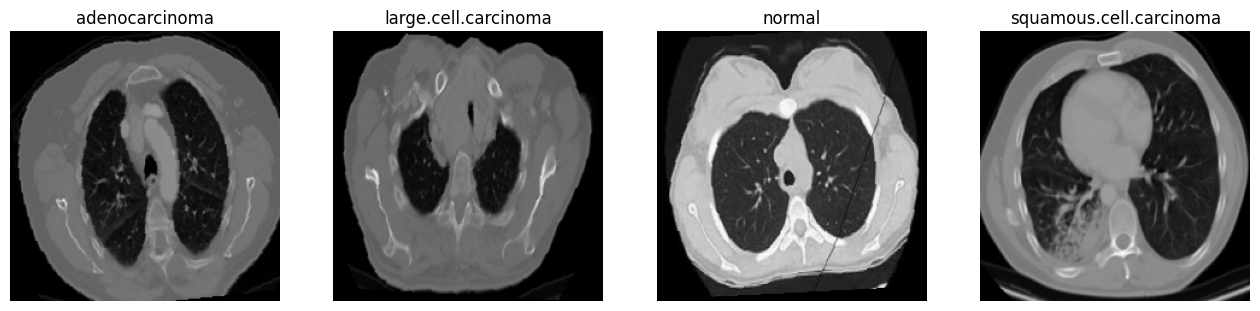

In [3]:
from src.plot.plot import plot_one_image_per_class

# Quick visual check: one transformed training image from each class.
plot_one_image_per_class(trainDataSet)


## 3. Create DataLoaders

DataLoaders group samples into mini-batches. The training loader shuffles data, while validation and test loaders keep a stable order.


In [4]:
from src.data.dataLoader import create_dataloaders

BATCH_SIZE = 32

train_loader, valid_loader, test_loader, classes = create_dataloaders(
    train_dir="data/train",
    valid_dir="data/valid",
    test_dir="data/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0
)

batch = next(iter(train_loader))
images = batch["image"]
labels = batch["label"]

print("Classes:", classes)
print("Images shape:", images.shape)  # [batch_size, channels, height, width]
print("Labels shape:", labels.shape)
print("Labels:", labels)


Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([2, 0, 0, 0, 3, 0, 0, 2, 1, 3, 2, 0, 0, 0, 0, 3, 2, 3, 2, 0, 0, 0, 0, 1,
        3, 2, 3, 2, 2, 3, 0, 3])


## 4. Check Class Imbalance

Medical datasets are often imbalanced. These plots show how many images each class has in each split. The training cells below use class-weighted cross entropy so minority classes receive more attention during optimization.


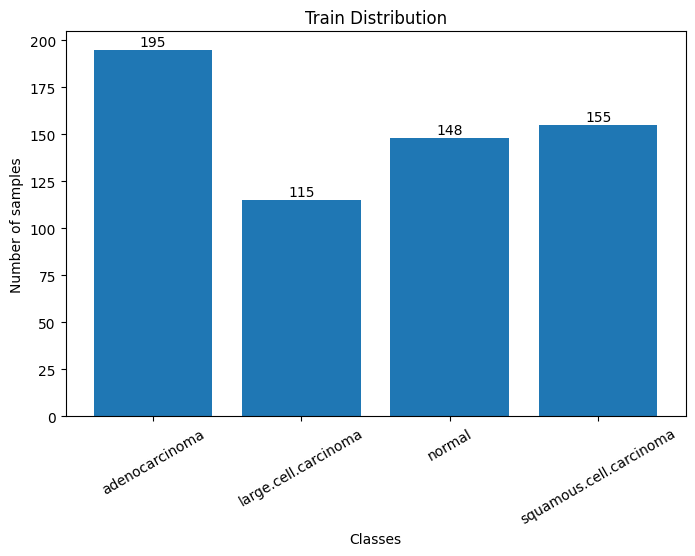

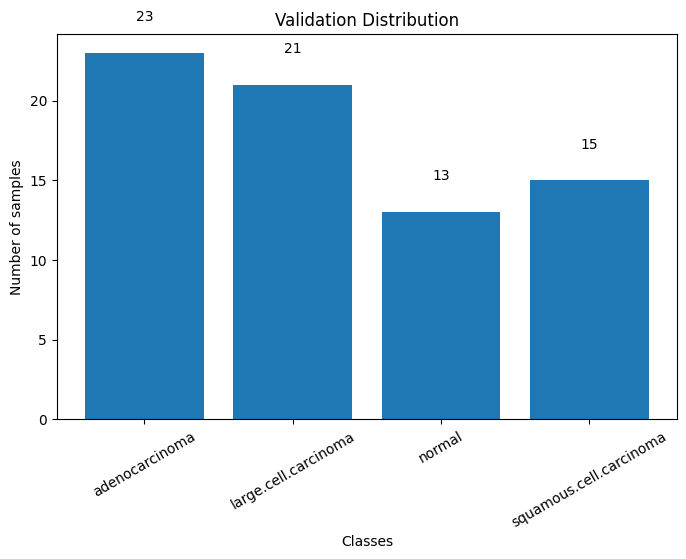

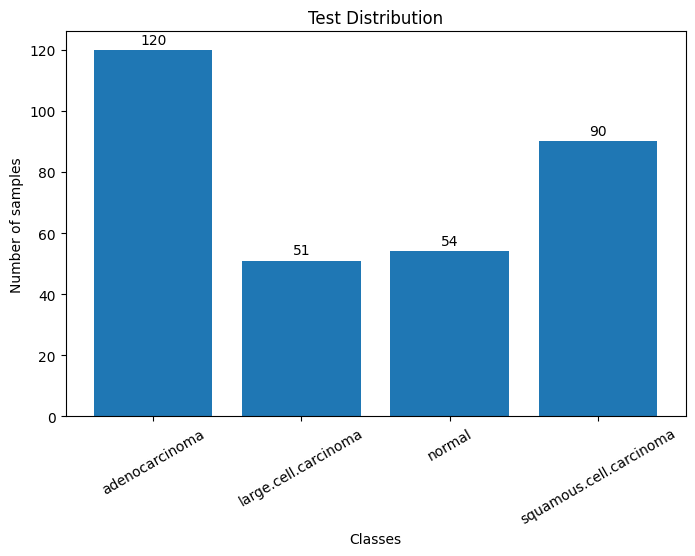

In [50]:
from src.plot.plot import plot_class_distribution

plot_class_distribution(trainDataSet, "Train Distribution")
plot_class_distribution(validDataSet, "Validation Distribution")
plot_class_distribution(testDataSet, "Test Distribution")

## 5. Baseline CNN: Forward-Pass Check

This quick check sends one batch through the baseline CNN. The output should have shape `[batch_size, number_of_classes]`, meaning the model returns one score per class for every image.


In [3]:
import torch
from src.model.cnn_baseline import CNNBaseline

baseline_model = CNNBaseline(num_classes=len(classes))

batch = next(iter(train_loader))
images = batch["image"]

outputs = baseline_model(images)

print("Output shape:", outputs.shape)  # [batch_size, num_classes]


Output shape: torch.Size([32, 4])


## 6. Train the Baseline CNN

The baseline model gives a simple reference point. If the larger ResNet does not improve over this model, that is a useful signal to inspect data quality, training settings, or overfitting.

The loss uses class weights computed from the training labels. Higher weights are assigned to underrepresented classes.


In [5]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

from src.model.cnn_baseline import CNNBaseline
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CNNBaseline(
    num_classes=len(classes),
    dropout=0.5
).to(device)

# Class weights
train_labels = []
for batch in train_loader:
    train_labels.extend(batch["label"].numpy())

print("Class distribution:", Counter(train_labels))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# Early stopping
num_epochs = 50
patience = 2
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

# Restore best model
model.load_state_dict(best_model_state)

print("\nCNNBaseline training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")

Using device: cpu
Class distribution: Counter({np.int64(0): 195, np.int64(3): 155, np.int64(2): 148, np.int64(1): 115})
Class weights: tensor([0.7859, 1.3326, 1.0355, 0.9887])

Epoch 1/50


Training:   0%|          | 0/20 [00:00<?, ?it/s]c:\Users\SWS\Desktop\Project\Cnn\Cnn\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation: 100%|██████████| 3/3 [00:00<00:00,  3.40it/s]


Train Loss: 1.2668 | Train Acc: 0.4209
Valid Loss: 1.2942 | Valid Acc: 0.4028
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.41it/s]


Train Loss: 1.1265 | Train Acc: 0.5171
Valid Loss: 1.1316 | Valid Acc: 0.4028
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 3/50


...

Train Loss: 1.0275 | Train Acc: 0.5269
Valid Loss: 1.0157 | Valid Acc: 0.4444
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 6/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.30it/s]


Train Loss: 1.0013 | Train Acc: 0.5008
Valid Loss: 1.0233 | Valid Acc: 0.4167
Learning Rate: 0.000050
No improvement for 1/2 epochs.

Epoch 7/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.40it/s]

Train Loss: 0.9849 | Train Acc: 0.5432
Valid Loss: 1.0326 | Valid Acc: 0.3889
Learning Rate: 0.000050
No improvement for 2/2 epochs.

Early stopping triggered.

CNNBaseline training complete.
Best epoch: 5
Best validation loss: 1.0157


## 7. Baseline Model Size

Counting parameters helps compare model complexity. A model with more parameters can learn richer patterns, but it can also overfit more easily on small datasets.


## 8. Evaluate the Baseline CNN

Evaluation runs on the held-out test set. The metrics summarize classification quality, the confusion matrix shows which classes are confused, and Grad-CAM images highlight the image regions that influenced selected predictions.


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]c:\Users\SWS\Desktop\Project\Cnn\Cnn\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating: 100%|██████████| 10/10 [00:04<00:00,  2.36it/s]


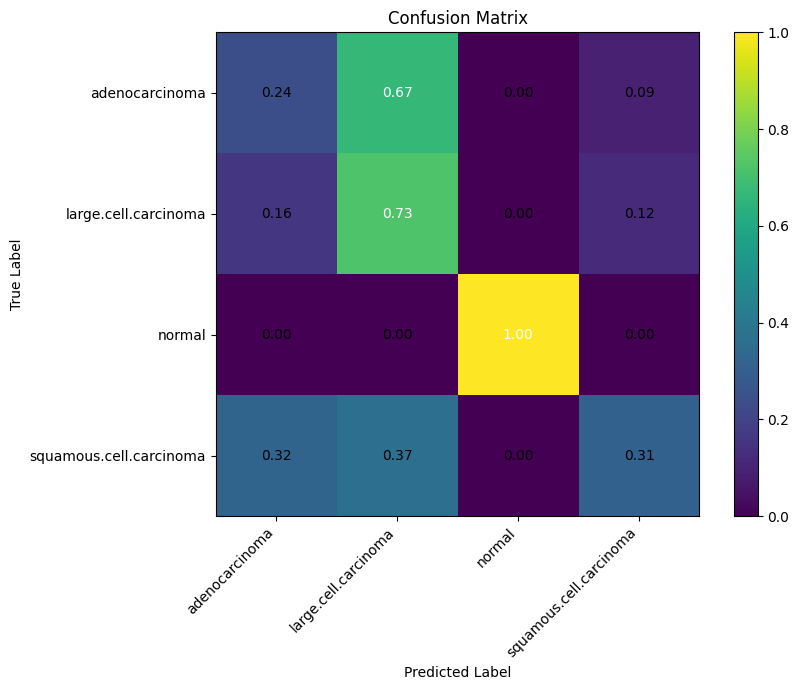

c:\Users\SWS\Desktop\Project\Cnn\Cnn\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Accuracy: 0.46984126984126984
Precision Macro: 0.5770707070707071
Recall Macro: 0.5695669934640524
F1 Macro: 0.5237004939460405

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.44      0.24      0.31       120
   large.cell.carcinoma       0.25      0.73      0.37        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.62      0.31      0.41        90

               accuracy                           0.47       315
              macro avg       0.58      0.57      0.52       315
           weighted avg       0.56      0.47  

In [7]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM saves visual explanations for a small set of test predictions.
    generate_gradcam=True,
    gradcam_save_dir="results/baseline/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])


## 9. Save Baseline Results

This saves the baseline metrics, configuration, and architecture outputs under `results/baseline`. Keeping the config beside the metrics makes the experiment easier to reproduce later.


In [ ]:
from src.Save.save import save_evaluation_results

baseline_config = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "loss_function": "Weighted CrossEntropyLoss"
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"]
    },
    model=model,
    save_dir="results/baseline",
    config=baseline_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("Baseline evaluation results and architecture saved successfully.")



(process:11308): Pango-WARNING **: 23:13:17.602: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/baseline\test_metrics.json
Model weights saved to: results/baseline\model.pth
Architecture image saved to: results/baseline\architecture.svg
Baseline evaluation results and architecture saved successfully.


## 10. Train ResNet18 From Scratch

This section trains a deeper ResNet18-style model without pretrained weights. It uses the same data, class-weighted loss, and optimizer family as the baseline so the comparison is easier to interpret.

The `history` dictionary stores train and validation loss/accuracy for each epoch.


In [9]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

from src.model.resnet import ResNet18Scratch
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResNet18Scratch(
    num_classes=len(classes)
).to(device)

# Class weights
train_labels = []
for batch in train_loader:
    train_labels.extend(batch["label"].numpy())

print("Class distribution:", Counter(train_labels))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# Early stopping
num_epochs = 50
patience = 5
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

# Restore best model
model.load_state_dict(best_model_state)

print("\nResNet18Scratch training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")


Using device: cpu
Class distribution: Counter({np.int64(0): 195, np.int64(3): 155, np.int64(2): 148, np.int64(1): 115})
Class weights: tensor([0.7859, 1.3326, 1.0355, 0.9887])

Epoch 1/50


Training:   0%|          | 0/20 [00:00<?, ?it/s]c:\Users\SWS\Desktop\Project\Cnn\Cnn\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation: 100%|██████████| 3/3 [00:01<00:00,  2.40it/s]


Train Loss: 1.0311 | Train Acc: 0.5334
Valid Loss: 2.4774 | Valid Acc: 0.2083
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.35it/s]


Train Loss: 0.9201 | Train Acc: 0.5775
Valid Loss: 1.2355 | Valid Acc: 0.4028
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 3/50


...

Train Loss: 0.1714 | Train Acc: 0.9429
Valid Loss: 0.8352 | Valid Acc: 0.7639
Learning Rate: 0.000025
No improvement for 3/5 epochs.

Epoch 16/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.25it/s]


Train Loss: 0.1410 | Train Acc: 0.9560
Valid Loss: 0.7666 | Valid Acc: 0.8056
Learning Rate: 0.000013
No improvement for 4/5 epochs.

Epoch 17/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.37it/s]

Train Loss: 0.1202 | Train Acc: 0.9527
Valid Loss: 0.7095 | Valid Acc: 0.8333
Learning Rate: 0.000013
No improvement for 5/5 epochs.

Early stopping triggered.

ResNet18Scratch training complete.
Best epoch: 12
Best validation loss: 0.6067


## 11. ResNet18 Model Size

This parameter count can be compared with the baseline CNN count above.


In [57]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print("Total params:", count_parameters(model))


Total params: 11178564


## 12. Reload Evaluation Helpers

This optional development cell reloads the Grad-CAM and evaluation modules. It is useful if you edit files in `src/interpretability` or `src/evaluation` while the notebook kernel is still running.


In [10]:
from importlib import reload
import src.interpretability.gradcam as gradcam_module
import src.evaluation.evaluate as evaluate_module

# Useful while developing the helper modules: reload changes without restarting the kernel.
reload(gradcam_module)
reload(evaluate_module)

evaluate_model = evaluate_module.evaluate_model


## 13. Evaluate the ResNet18 Model

This repeats the same test-set evaluation used for the baseline model. Comparing the two sets of metrics shows whether the deeper architecture improves performance, and the Grad-CAM outputs help inspect whether the model focuses on plausible CT scan regions.


Evaluating: 100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


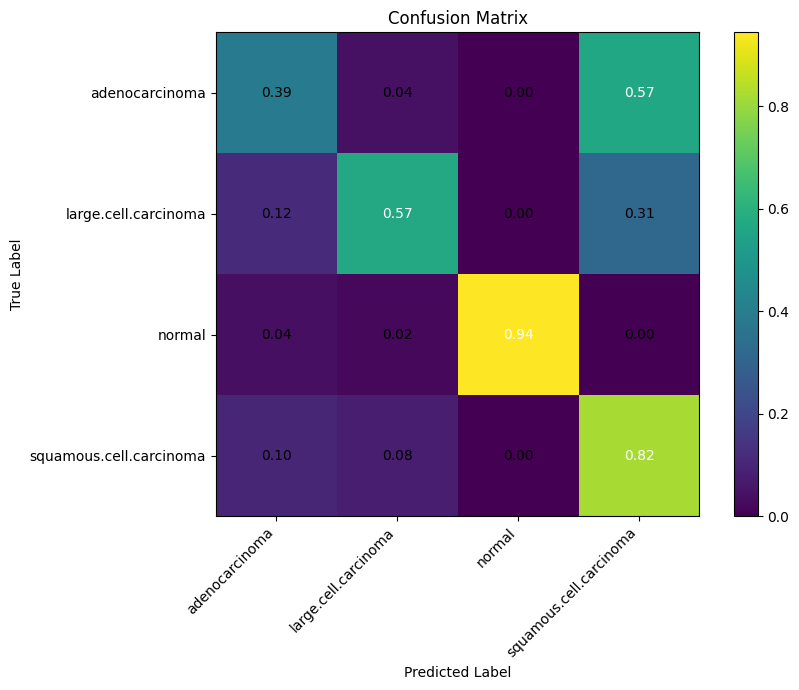

c:\Users\SWS\Desktop\Project\Cnn\Cnn\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Accuracy: 0.638095238095238
Precision Macro: 0.7233014052139843
Recall Macro: 0.6817401960784313
F1 Macro: 0.6756820610432112

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.73      0.39      0.51       120
   large.cell.carcinoma       0.69      0.57      0.62        51
                 normal       1.00      0.94      0.97        54
squamous.cell.carcinoma       0.47      0.82      0.60        90

               accuracy                           0.64       315
              macro avg       0.72      0.68      0.68       315
           weigh

In [11]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM saves visual explanations for a small set of test predictions.
    generate_gradcam=True,
    gradcam_save_dir="results/Resnet/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])


## 14. Save ResNet18 Results

This saves the ResNet18 metrics and experiment configuration under `results/Resnet`. These files can be used later for reporting, comparison, or dashboard display.


In [12]:
from src.Save.save import save_evaluation_results

resnet_config = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "loss_function": "Weighted CrossEntropyLoss",
    "scheduler": "StepLR(step_size=5, gamma=0.5)"
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"]
    },
    model=model,
    save_dir="results/Resnet",
    config=resnet_config,
    filename="test_metrics.json"
)

print("ResNet18 evaluation results saved successfully.")



(process:1536): Pango-WARNING **: 23:23:46.033: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/Resnet\test_metrics.json
Model weights saved to: results/Resnet\model.pth
Architecture image saved to: results/Resnet\architecture.svg
ResNet18 evaluation results saved successfully.


In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

from src.model.vgg16 import VGG16Scratch
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = VGG16Scratch(
    num_classes=len(classes),
    dropout=0.5
).to(device)

# Recompute class weights
train_labels = []
for batch in train_loader:
    train_labels.extend(batch["label"].numpy())

print("Class distribution:", Counter(train_labels))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

num_epochs = 3

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

print("\nVGG16Scratch training complete.")

Using device: cpu
Class distribution: Counter({np.int64(0): 195, np.int64(3): 155, np.int64(2): 148, np.int64(1): 115})
Class weights: tensor([0.7859, 1.3326, 1.0355, 0.9887])

Epoch 1/3


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.13s/it]


Train Loss: 1.3302 | Train Acc: 0.4192
Valid Loss: 1.7014 | Valid Acc: 0.2917

Epoch 2/3


Validation: 100%|██████████| 3/3 [00:07<00:00,  2.40s/it]


Train Loss: 1.1609 | Train Acc: 0.4568
Valid Loss: 1.0795 | Valid Acc: 0.4028

Epoch 3/3


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.15s/it]

Train Loss: 1.1969 | Train Acc: 0.4780
Valid Loss: 1.0221 | Valid Acc: 0.5139

VGG16Scratch training complete.


Evaluating: 100%|██████████| 10/10 [00:28<00:00,  2.82s/it]


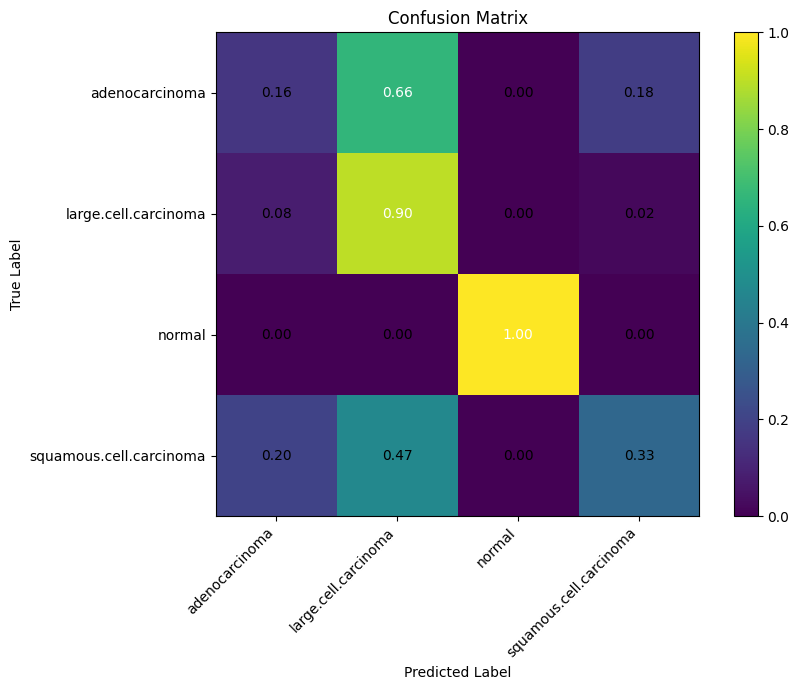

Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Accuracy: 0.473015873015873
Precision Macro: 0.5762253679479513
Recall Macro: 0.5984068627450981
F1 Macro: 0.5194059032311924

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.46      0.16      0.24       120
   large.cell.carcinoma       0.28      0.90      0.42        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.57      0.33      0.42        90

               accuracy                           0.47       315
              macro avg       0.58      0.60      0.52       315
           weighted avg       0.55      

In [64]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM for VGG16Scratch
    generate_gradcam=True,
    gradcam_save_dir="results/vgg16_scratch/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])

In [65]:
from src.Save.save import save_evaluation_results

vgg16_config = {
    "model_name": "VGG16Scratch",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "loss_function": "Weighted CrossEntropyLoss",
    "scheduler": "StepLR(step_size=5, gamma=0.5)",
    "dropout": 0.5,

    # Deployment requirements
    "class_names": classes,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225]
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },

    model=model,

    save_dir="results/vgg16_scratch",

    config=vgg16_config,

    filename="test_metrics.json",

    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("VGG16Scratch evaluation results saved successfully.")


(process:9256): Pango-WARNING **: 22:50:58.778: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/vgg16_scratch\test_metrics.json
Model weights saved to: results/vgg16_scratch\model.pth
Architecture image saved to: results/vgg16_scratch\architecture.svg
VGG16Scratch evaluation results saved successfully.


In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

from src.model.vgg16 import VGG16Scratch
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = VGG16Scratch(
    num_classes=len(classes),
    dropout=0.5
).to(device)

# Recompute class weights
train_labels = []
for batch in train_loader:
    train_labels.extend(batch["label"].numpy())

print("Class distribution:", Counter(train_labels))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# =========================
# Early Stopping Config
# =========================
num_epochs = 50
patience = 7

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

    # =========================
    # Early stopping check
    # =========================
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1

        print("Validation loss improved. Best model updated.")

    else:
        epochs_without_improvement += 1

        print(
            f"No improvement for {epochs_without_improvement}/{patience} epochs."
        )

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nVGG16Scratch training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")

# 16. Training EfficientNetB3

In [6]:
import torch
# ── Paths ────────────────────────────────────────────────────────────────────
TRAIN_DIR  = "data/train"       # <- change to your actual path
VALID_DIR  = "data/valid"       # <- change to your actual path
TEST_DIR   = "data/test"        # <- change to your actual path
SAVE_DIR   = "checkpoints"

# ── Hyper-parameters ─────────────────────────────────────────────────────────
IMAGE_SIZE   = 300              # native EfficientNet-B3 resolution (Option 1)
BATCH_SIZE   = 2               # safe default for 8 GB VRAM; raise to 32 for 16 GB+
NUM_WORKERS  = 4
EPOCHS       = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-2
PRETRAINED   = True

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda")
print(torch.cuda.is_available())
print(f"Device : {DEVICE}")
print(f"Image size : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(torch.cuda.get_device_name(0))


True
Device : cuda
Image size : 300x300
NVIDIA GeForce GTX 960M


In [9]:
## Training EfficientNetB3
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

from src.model.efficientnetb3 import EfficientNetB3
from src.training.training import train_one_epoch, validate_one_epoch

from src.data.dataLoader import create_dataloaders
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = EfficientNetB3(num_classes=4, pretrained=PRETRAINED)
model = model.to(DEVICE)

train_loader, valid_loader, test_loader, classes = create_dataloaders(
    train_dir=TRAIN_DIR,
    valid_dir=VALID_DIR,
    test_dir=TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)


train_labels = []
for batch in train_loader:
    train_labels.extend(batch["label"].numpy())

print("Class distribution:", Counter(train_labels))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)

# Early stopping
num_epochs = 50
patience = 5
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    '''if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break'''

# Restore best model
model.load_state_dict(best_model_state)

print("\nEfficientNetB3 training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")

Using device: cuda
Class distribution: Counter({np.int64(0): 195, np.int64(3): 155, np.int64(2): 148, np.int64(1): 115})
Class weights: tensor([0.7859, 1.3326, 1.0355, 0.9887], device='cuda:0')

Epoch 1/50


Validation: 100%|██████████| 36/36 [00:09<00:00,  3.97it/s]


Train Loss: 1.1314 | Train Acc: 0.5171
Valid Loss: 357.6135 | Valid Acc: 0.6944
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 36/36 [00:08<00:00,  4.02it/s]


Train Loss: 0.8466 | Train Acc: 0.6656
Valid Loss: 9.5583 | Valid Acc: 0.7361
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 3/50


...

Train Loss: 0.0183 | Train Acc: 0.9967
Valid Loss: 8.7804 | Valid Acc: 0.9028
Learning Rate: 0.000061
No improvement for 11/5 epochs.

Epoch 49/50


Validation: 100%|██████████| 36/36 [00:09<00:00,  3.93it/s]


Train Loss: 0.0144 | Train Acc: 0.9935
Valid Loss: 258.5215 | Valid Acc: 0.8750
Learning Rate: 0.000066
No improvement for 12/5 epochs.

Epoch 50/50


Validation: 100%|██████████| 36/36 [00:08<00:00,  4.04it/s]

Train Loss: 0.0167 | Train Acc: 0.9935
Valid Loss: 31.8626 | Valid Acc: 0.8889
Learning Rate: 0.000071
No improvement for 13/5 epochs.

EfficientNetB3 training complete.
Best epoch: 37
Best validation loss: 0.1635


# Training History

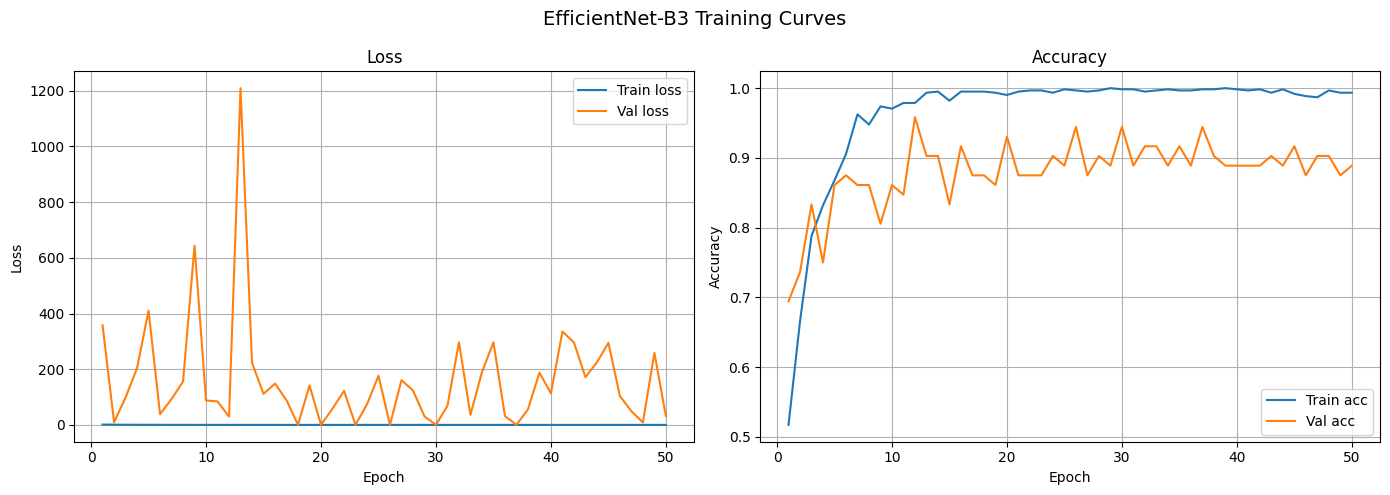

In [20]:
import os
import matplotlib.pyplot as plt

epochs_range = range(1, 51)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history["train_loss"], label="Train loss")
ax1.plot(epochs_range, history["valid_loss"],   label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs_range, history["train_acc"], label="Train acc")
ax2.plot(epochs_range, history["valid_acc"],   label="Val acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("EfficientNet-B3 Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

# Evaluation

Evaluating: 100%|██████████| 158/158 [00:15<00:00, 10.33it/s]


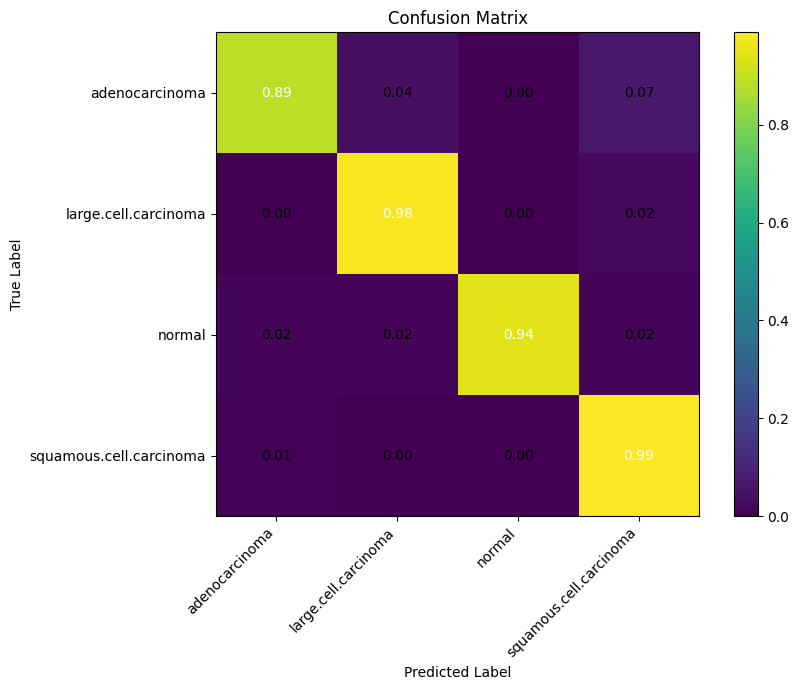

Grad-CAM target layer selected: features.8.0
Grad-CAM target layer selected: features.8.0
Grad-CAM target layer selected: features.8.0
Grad-CAM target layer selected: features.8.0
Grad-CAM target layer selected: features.8.0
Grad-CAM target layer selected: features.8.0
Grad-CAM target layer selected: features.8.0
Grad-CAM target layer selected: features.8.0
Accuracy: 0.9428571428571428
Precision Macro: 0.9433746044984577
Recall Macro: 0.9513480392156863
F1 Macro: 0.945576192268434

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.98      0.89      0.93       120
   large.cell.carcinoma       0.89      0.98      0.93        51
                 normal       1.00      0.94      0.97        54
squamous.cell.carcinoma       0.90      0.99      0.94        90

               accuracy                           0.94       315
              macro avg       0.94      0.95      0.95       315
           weighted avg       0.

In [12]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,
    generate_gradcam=True,
    gradcam_save_dir="results/efcnetb3/gradcam",
    num_gradcam_images=8
)
'''
# Grad-CAM for EfficientNetB3
    generate_gradcam=True,
    gradcam_save_dir="results/efcnetb3/gradcam",
    num_gradcam_images=8
    '''

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])

# Save EfficientNetB3 Results

In [23]:
from src.Save.save import save_evaluation_results

baseline_config = {
    "image_size": 300,
    "batch_size": 2,
    "epochs": 50,
    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "loss_function": "Weighted CrossEntropyLoss"
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"]
    },
    model=model,
    save_dir="results/efcnetb3",
    config=baseline_config,
    filename="test_metrics.json",
    input_size=(1, 3, 300, 300)
)

print("EfficientNetB3 evaluation results and architecture saved successfully.")

Architecture visualization skipped: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH
Evaluation results saved to: results/efcnetb3\test_metrics.json
Model weights saved to: results/efcnetb3\model.pth
Architecture image saved to: results/efcnetb3\architecture.svg
EfficientNetB3 evaluation results and architecture saved successfully.
